# 📊 DỰ ÁN KHAI PHÁ DỮ LIỆU: DỰ ĐOÁN THU NHẬP CÓ VƯỢT 50K/NĂM

## Mục tiêu
Xây dựng mô hình máy học để **dự đoán liệu một người có kiếm được trên 50K USD/năm hay không** dựa trên các đặc tính nhân khẩu học từ cơ sở dữ liệu Điều tra Dân số Mỹ năm 1994.

---
**Nguồn dữ liệu**: UCI Adult Income Dataset (Kaggle: [adult.csv](https://www.kaggle.com/datasets/wenruliu/adult-income-dataset/data))  
**Các mô hình**: Perceptron · Naïve Bayes · Linear SVM · Radial SVM · Logistic Regression · Random Forest · KNN


## 1️⃣ IMPORT THƯ VIỆN

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

# Cài đặt hiển thị
pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 100})

print("✅ Tất cả thư viện đã được import thành công.")


✅ Tất cả thư viện đã được import thành công.


## 2️⃣ TẢI VÀ KHÁM PHÁ DỮ LIỆU

In [2]:
# ── Tải dữ liệu ──────────────────────────────────────────────────────
# BUG FIX: Thêm fallback từ UCI nếu không tìm thấy file 'adult.csv' local
import os

LOCAL_PATH = 'adult.csv'
UCI_URL    = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'

UCI_COLUMNS = [
    'age','workclass','fnlwgt','education','educational-num',
    'marital-status','occupation','relationship','race','sex',
    'capital-gain','capital-loss','hours-per-week','native-country','income'
]

if os.path.exists(LOCAL_PATH):
    df = pd.read_csv(LOCAL_PATH)
    print(f"✅ Đọc dữ liệu từ file local: {LOCAL_PATH}")
else:
    print("⚠️  Không tìm thấy 'adult.csv'. Đang tải từ UCI Repository...")
    df = pd.read_csv(UCI_URL, names=UCI_COLUMNS,
                     na_values=' ?', skipinitialspace=True)
    print("✅ Tải dữ liệu từ UCI thành công.")

print(f"\n📊 Kích thước dataset: {df.shape}")
df.head()


✅ Đọc dữ liệu từ file local: adult.csv

📊 Kích thước dataset: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [4]:
# Kiểm tra missing values
print("🔍 Tỷ lệ missing values (%):")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage(%)': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

# BUG FIX: Kiểm tra thêm giá trị '?' (dạng string missing)
print("\n🔍 Giá trị '?' trong các cột dạng chuỗi:")
col_str = df.select_dtypes(include=['object']).columns.tolist()
for c in col_str:
    n_qm = (df[c] == '?').sum()
    if n_qm > 0:
        print(f"  {c}: {n_qm} giá trị '?'")


🔍 Tỷ lệ missing values (%):
Empty DataFrame
Columns: [Missing, Percentage(%)]
Index: []

🔍 Giá trị '?' trong các cột dạng chuỗi:
  workclass: 2799 giá trị '?'
  occupation: 2809 giá trị '?'
  native-country: 857 giá trị '?'


In [5]:
# Liệt kê các cột dạng chuỗi
col = df.select_dtypes(include=['object']).columns.tolist()
print("Các cột dạng chuỗi:", col)


Các cột dạng chuỗi: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


## 3️⃣ DATA CLEANING

In [6]:
# ── Xử lý missing values ─────────────────────────────────────────────
df['age'] = df['age'].astype(float)
df['hours-per-week'] = df['hours-per-week'].astype(float)

df_clean = df.copy()

# BUG FIX 1: Lấy đúng danh sách cột object TRƯỚC khi xử lý
# (tránh lỗi nếu biến 'col' bị overwrite ở bước sau)
col_obj = df_clean.select_dtypes(include=['object']).columns.tolist()

# Thay thế '?' bằng mode của từng cột
for c in col_obj:
    mode_val = df_clean[c].mode()[0]
    df_clean[c] = df_clean[c].replace('?', mode_val)

print("✅ Đã xử lý '?' bằng mode.")

# BUG FIX 2: Chuẩn hóa cột 'income' — strip khoảng trắng & chuẩn hóa ký tự
# (UCI download có thể có ' <=50K' với khoảng trắng đầu dòng)
df_clean['income'] = df_clean['income'].str.strip().str.replace('.', '', regex=False)
print("✅ Giá trị income:", df_clean['income'].unique())

# Đổi tên cột target
df_clean['predclass'] = df_clean['income']
df_clean.drop(columns=['income'], inplace=True)

# BUG FIX 3: Rename 'educational-num' an toàn (Kaggle có thể đặt tên khác)
# Dùng rename + errors='ignore' thay vì del để không crash khi cột không tồn tại
if 'educational-num' in df_clean.columns:
    df_clean.rename(columns={'educational-num': 'education-num'}, inplace=True)
elif 'education.num' in df_clean.columns:
    df_clean.rename(columns={'education.num': 'education-num'}, inplace=True)
# Nếu cột đã tên đúng thì bỏ qua

print(f"\n✅ Dữ liệu sau làm sạch: {df_clean.shape}")
print(df_clean.head())


✅ Đã xử lý '?' bằng mode.
✅ Giá trị income: <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str

✅ Dữ liệu sau làm sạch: (48842, 15)
    age  workclass  fnlwgt     education  education-num      marital-status  \
0  25.0    Private  226802          11th              7       Never-married   
1  38.0    Private   89814       HS-grad              9  Married-civ-spouse   
2  28.0  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3  44.0    Private  160323  Some-college             10  Married-civ-spouse   
4  18.0    Private  103497  Some-college             10       Never-married   

          occupation relationship   race  gender  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688        

## 4️⃣ KỸ THUẬT TẠO ĐẶC TÍNH (FEATURE ENGINEERING)

In [7]:
print("📚 Gom nhóm Education...")

dropout_levels = ['Preschool', '10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th']
for level in dropout_levels:
    df_clean['education'] = df_clean['education'].replace(level, 'dropout')

df_clean['education'] = df_clean['education'].replace(['HS-Grad', 'HS-grad'], 'HighGrad')
df_clean['education'] = df_clean['education'].replace(['Some-college', 'Assoc-acdm', 'Assoc-voc'], 'CommunityCollege')
df_clean['education'] = df_clean['education'].replace(['Prof-school'], 'Masters')

print("✅ Các mức education sau gom nhóm:")
print(df_clean['education'].value_counts())


📚 Gom nhóm Education...
✅ Các mức education sau gom nhóm:
education
HighGrad            15784
CommunityCollege    14540
Bachelors            8025
dropout              6408
Masters              3491
Doctorate             594
Name: count, dtype: int64


In [8]:
print("💍 Gom nhóm Marital Status...")

df_clean['marital-status'] = df_clean['marital-status'].replace('Never-married', 'NotMarried')
df_clean['marital-status'] = df_clean['marital-status'].replace(
    ['Married-AF-spouse', 'Married-civ-spouse'], 'Married'
)
df_clean['marital-status'] = df_clean['marital-status'].replace('Married-spouse-absent', 'NotMarried')
df_clean['marital-status'] = df_clean['marital-status'].replace(
    ['Separated', 'Divorced'], 'Separated'
)

print("✅ Các tình trạng hôn nhân sau gom nhóm:")
print(df_clean['marital-status'].value_counts())


💍 Gom nhóm Marital Status...
✅ Các tình trạng hôn nhân sau gom nhóm:
marital-status
Married       22416
NotMarried    16745
Separated      8163
Widowed        1518
Name: count, dtype: int64


In [9]:
print("🎯 Tạo đặc tính phân chia (Binned Features) và tương tác...")

df_clean['age_bin']          = pd.cut(df_clean['age'], bins=20)
df_clean['hours-per-week_bin'] = pd.cut(df_clean['hours-per-week'], bins=10)
df_clean['age-hours']        = df_clean['age'] * df_clean['hours-per-week']

print("✅ Các đặc tính tương tác đã được tạo")
print(df_clean[['age_bin','hours-per-week_bin','age-hours']].head(3))


🎯 Tạo đặc tính phân chia (Binned Features) và tương tác...
✅ Các đặc tính tương tác đã được tạo
         age_bin hours-per-week_bin  age-hours
0  (24.3, 27.95]       (30.4, 40.2]     1000.0
1  (35.25, 38.9]       (40.2, 50.0]     1900.0
2  (27.95, 31.6]       (30.4, 40.2]     1120.0


## 5️⃣ PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

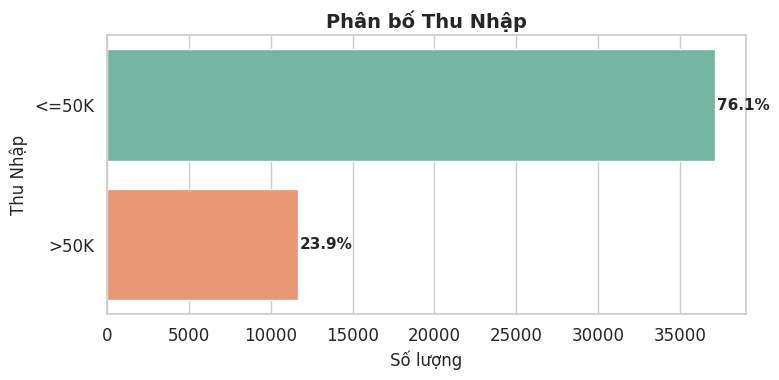

📊 Thống kê thu nhập:
  <=50K: 37155 (76.1%)
  >50K: 11687 (23.9%)


In [10]:
# Phân bố biến mục tiêu
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_clean, y='predclass', palette='Set2', order=df_clean['predclass'].value_counts().index)
plt.title('Phân bố Thu Nhập', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng', fontsize=12)
plt.ylabel('Thu Nhập', fontsize=12)

# Thêm nhãn phần trăm
total = len(df_clean)
for p in ax.patches:
    pct = f'{100*p.get_width()/total:.1f}%'
    ax.annotate(pct, (p.get_width()+100, p.get_y()+p.get_height()/2),
                va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 Thống kê thu nhập:")
vc = df_clean['predclass'].value_counts()
for k,v in vc.items():
    print(f"  {k}: {v} ({v/total*100:.1f}%)")


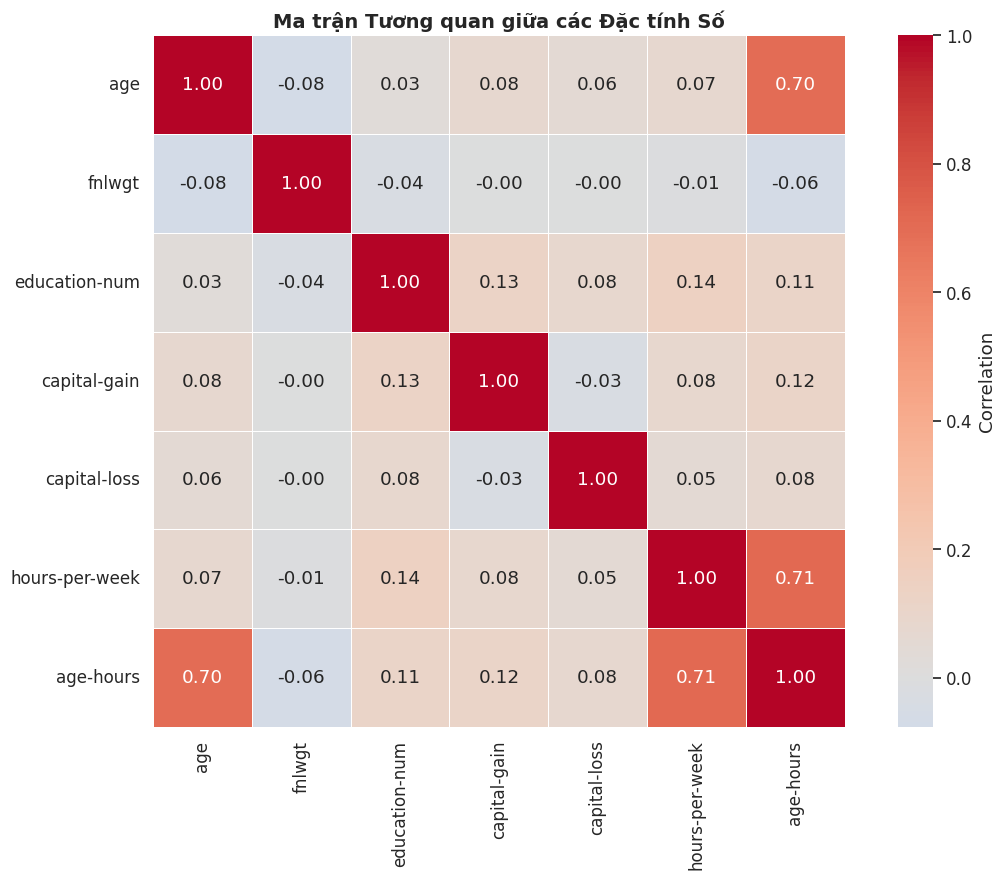

In [11]:
# Ma trận tương quan
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation'})
plt.title('Ma trận Tương quan giữa các Đặc tính Số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


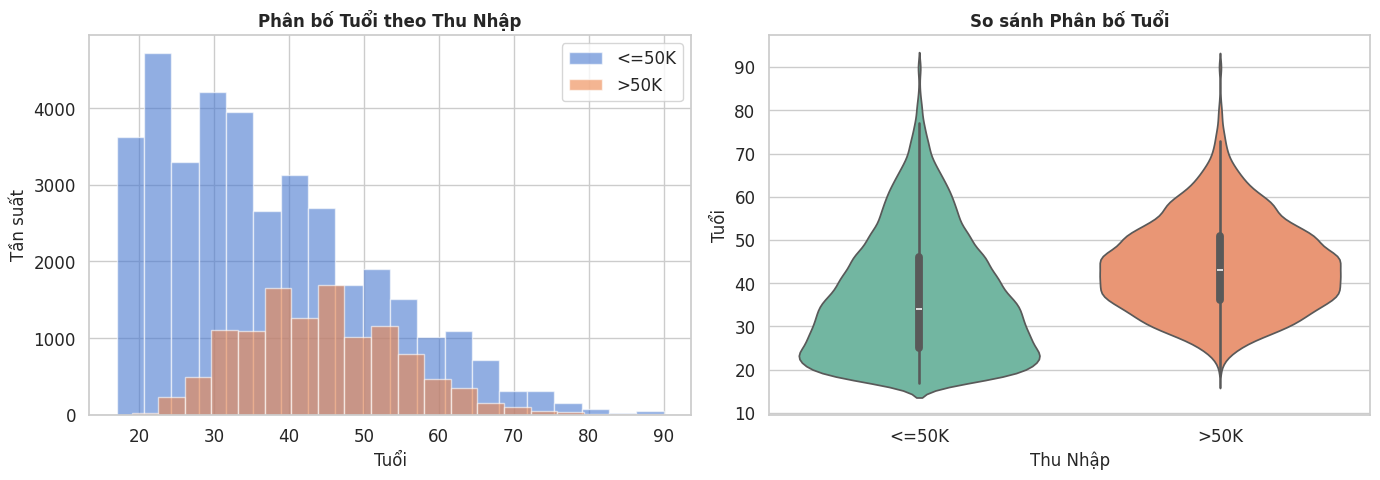

📊 Tuổi trung bình theo thu nhập:
predclass
<=50K    36.87
>50K     44.28
Name: age, dtype: float64


In [12]:
# Phân bố tuổi theo thu nhập
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for income_val in df_clean['predclass'].unique():
    data = df_clean[df_clean['predclass'] == income_val]['age']
    axes[0].hist(data, alpha=0.6, label=income_val, bins=20)
axes[0].set_xlabel('Tuổi', fontsize=12)
axes[0].set_ylabel('Tần suất', fontsize=12)
axes[0].set_title('Phân bố Tuổi theo Thu Nhập', fontsize=12, fontweight='bold')
axes[0].legend()

# BUG FIX: violinplot — dùng hue thay vì x để tránh FutureWarning trong seaborn mới
sns.violinplot(data=df_clean, x='predclass', y='age', ax=axes[1],
               hue='predclass', palette='Set2', legend=False)
axes[1].set_title('So sánh Phân bố Tuổi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thu Nhập', fontsize=12)
axes[1].set_ylabel('Tuổi', fontsize=12)

plt.tight_layout()
plt.show()

print("📊 Tuổi trung bình theo thu nhập:")
print(df_clean.groupby('predclass')['age'].mean().round(2))


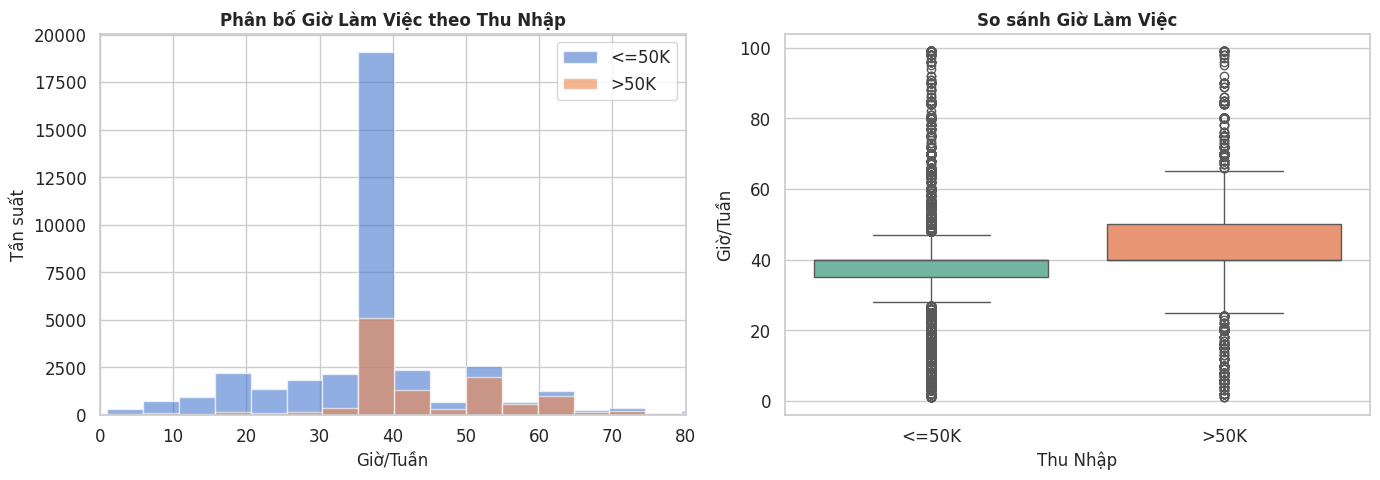

📊 Giờ làm việc trung bình theo thu nhập:
predclass
<=50K    38.84
>50K     45.45
Name: hours-per-week, dtype: float64


In [13]:
# Giờ làm việc theo thu nhập
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for income_val in df_clean['predclass'].unique():
    data = df_clean[df_clean['predclass'] == income_val]['hours-per-week']
    axes[0].hist(data, alpha=0.6, label=income_val, bins=20)
axes[0].set_xlabel('Giờ/Tuần', fontsize=12)
axes[0].set_ylabel('Tần suất', fontsize=12)
axes[0].set_title('Phân bố Giờ Làm Việc theo Thu Nhập', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 80)

# BUG FIX: boxplot — dùng hue thay vì x để tránh FutureWarning seaborn mới
sns.boxplot(data=df_clean, x='predclass', y='hours-per-week', ax=axes[1],
            hue='predclass', palette='Set2', legend=False)
axes[1].set_title('So sánh Giờ Làm Việc', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thu Nhập', fontsize=12)
axes[1].set_ylabel('Giờ/Tuần', fontsize=12)

plt.tight_layout()
plt.show()

print("📊 Giờ làm việc trung bình theo thu nhập:")
print(df_clean.groupby('predclass')['hours-per-week'].mean().round(2))


## 6️⃣ TIỀN XỬ LÝ DỮ LIỆU (PREPROCESSING)

In [14]:
print("🔹 Lựa chọn và mã hóa đặc tính cho mô hình...")
df_model = df_clean.copy()

# BUG FIX: Biến vòng lặp 'col' sẽ ghi đè biến 'col' được dùng trước đó
# → Đổi thành tên khác 'enc_col' để tránh conflict
le = LabelEncoder()
for enc_col in df_model.select_dtypes(include=['object', 'category']).columns:
    df_model[enc_col] = le.fit_transform(df_model[enc_col].astype(str))

print(f"✅ Label Encoding hoàn tất. Shape: {df_model.shape}")
print(df_model.dtypes)
print()
print(df_model.head())


🔹 Lựa chọn và mã hóa đặc tính cho mô hình...
✅ Label Encoding hoàn tất. Shape: (48842, 18)
age                   float64
workclass               int64
fnlwgt                  int64
education               int64
education-num           int64
marital-status          int64
occupation              int64
relationship            int64
race                    int64
gender                  int64
capital-gain            int64
capital-loss            int64
hours-per-week        float64
native-country          int64
predclass               int64
age_bin                 int64
hours-per-week_bin      int64
age-hours             float64
dtype: object

    age  workclass  fnlwgt  education  education-num  marital-status  \
0  25.0          3  226802          5              7               1   
1  38.0          3   89814          3              9               0   
2  28.0          1  336951          1             12               0   
3  44.0          3  160323          1             10              

## 7️⃣ CHIA DỮ LIỆU TRAIN-TEST

In [15]:
# Chuẩn bị X và y
# BUG FIX: Loại bỏ thêm 'age_bin' và 'hours-per-week_bin' vì đây là
# Categorical (Interval) sau pd.cut, không tương thích với sklearn khi không encode
# Đã encode ở bước trên nhưng để rõ ràng vẫn drop
drop_cols = ['education', 'native-country', 'predclass',
             'age_bin', 'hours-per-week_bin']

X = df_model.drop(columns=drop_cols, errors='ignore')
y = df_model['predclass']

print(f"📊 Đặc tính sử dụng: {list(X.columns)}")
print(f"📊 Kích thước X: {X.shape}")

# BUG FIX: Thêm stratify=y để giữ tỷ lệ class imbalance (76/24%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Training set: {X_train.shape}  ({y_train.value_counts(normalize=True).round(3).to_dict()})")
print(f"📊 Test set    : {X_test.shape}  ({y_test.value_counts(normalize=True).round(3).to_dict()})")

# Chuẩn hóa dữ liệu (cần thiết cho Perceptron, SVM, KNN, Logistic)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\n✅ Chia và chuẩn hóa dữ liệu thành công.")


📊 Đặc tính sử dụng: ['age', 'workclass', 'fnlwgt', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'age-hours']
📊 Kích thước X: (48842, 13)

📊 Training set: (39073, 13)  ({0: 0.761, 1: 0.239})
📊 Test set    : (9769, 13)  ({0: 0.761, 1: 0.239})

✅ Chia và chuẩn hóa dữ liệu thành công.


## 8️⃣ SO SÁNH NHANH CÁC MÔ HÌNH

📊 BẢNG SO SÁNH ĐỘ CHÍNH XÁC CÁC MÔ HÌNH:
Mô hình                           Độ chính xác
------------------------------------------------------------
Random Forest                  0.8591 (85.91%) 🏆
Radial SVM                     0.8529 (85.29%)
Linear SVM                     0.8440 (84.40%)
Logistic Regression            0.8414 (84.14%)
KNN                            0.8412 (84.12%)
Perceptron                     0.8107 (81.07%)
Gaussian Naive Bayes           0.7981 (79.81%)

🏆 MÔ HÌNH TỐT NHẤT: Random Forest
   Độ chính xác: 0.8591 (85.91%)


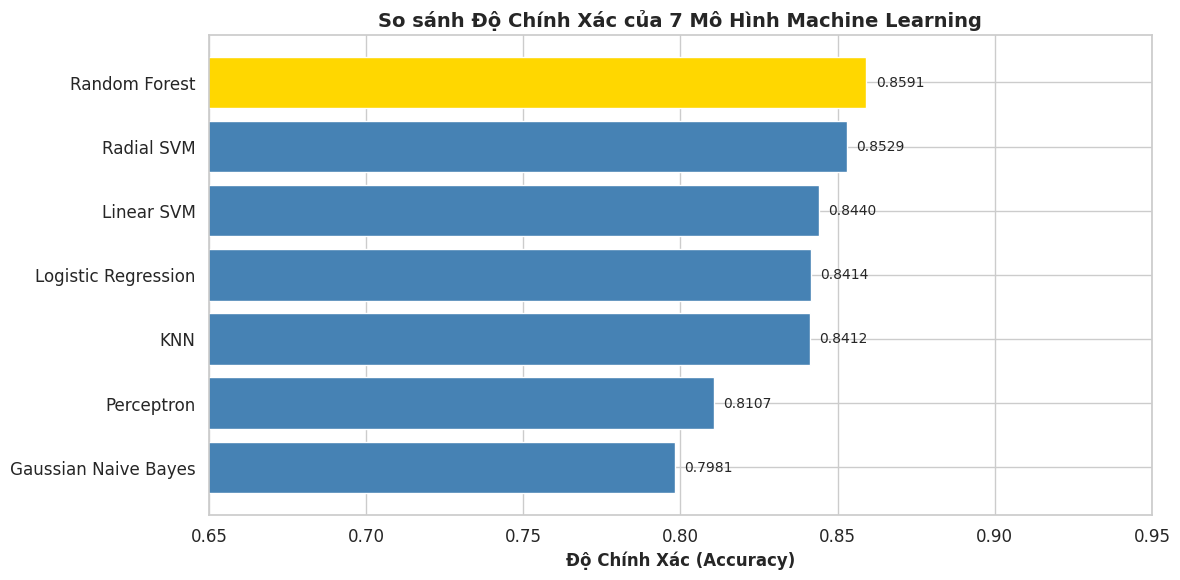

In [16]:
def evaluate_models(X_train_raw, y_train, X_test_raw,
                    X_train_sc, X_test_sc, y_test):
    """
    Đánh giá 7 mô hình. Dùng dữ liệu đã chuẩn hóa (sc) cho các mô hình
    nhạy cảm với scale (Perceptron, SVM, KNN, Logistic Regression).
    """
    # BUG FIX 1: SVC(kernel='linear', gamma='auto') → gamma không hợp lệ với linear kernel
    # BUG FIX 2: Perceptron và SVM phải dùng X_train_sc / X_test_sc
    models_scaled = {
        'Perceptron'        : Perceptron(random_state=42, max_iter=1000),
        'Linear SVM'        : SVC(kernel='linear', random_state=42),      # Bỏ gamma='auto'
        'Radial SVM'        : SVC(kernel='rbf', gamma=0.22, random_state=42),
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'KNN'               : KNeighborsClassifier(n_neighbors=9),
    }
    models_raw = {
        'Gaussian Naive Bayes': GaussianNB(),
        'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    }

    results = []
    for name, model in models_scaled.items():
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)
        acc = accuracy_score(y_test, y_pred)
        results.append((name, acc))

    for name, model in models_raw.items():
        model.fit(X_train_raw, y_train)
        y_pred = model.predict(X_test_raw)
        acc = accuracy_score(y_test, y_pred)
        results.append((name, acc))

    results = sorted(results, key=lambda x: x[1], reverse=True)

    print("📊 BẢNG SO SÁNH ĐỘ CHÍNH XÁC CÁC MÔ HÌNH:")
    print("="*60)
    print(f"{'Mô hình':<30} {'Độ chính xác':>15}")
    print("-"*60)
    for name, acc in results:
        marker = " 🏆" if name == results[0][0] else ""
        print(f"{name:<30} {acc:.4f} ({acc*100:.2f}%){marker}")
    print("="*60)

    print(f"\n🏆 MÔ HÌNH TỐT NHẤT: {results[0][0]}")
    print(f"   Độ chính xác: {results[0][1]:.4f} ({results[0][1]*100:.2f}%)")

    # Biểu đồ
    models_df = pd.DataFrame(results, columns=['Mô hình', 'Test Accuracy'])
    models_df = models_df.sort_values('Test Accuracy')
    colors = ['gold' if i == len(models_df)-1 else 'steelblue'
              for i in range(len(models_df))]

    plt.figure(figsize=(12, 6))
    bars = plt.barh(models_df['Mô hình'], models_df['Test Accuracy'], color=colors)
    plt.xlabel('Độ Chính Xác (Accuracy)', fontsize=12, fontweight='bold')
    plt.title('So sánh Độ Chính Xác của 7 Mô Hình Machine Learning',
              fontsize=14, fontweight='bold')
    plt.xlim([0.65, 0.95])
    for bar, (_, row) in zip(bars, models_df.iterrows()):
        plt.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{row["Test Accuracy"]:.4f}', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()

    return results

results_quick = evaluate_models(X_train, y_train, X_test,
                                 X_train_sc, X_test_sc, y_test)


## 9️⃣ XÂY DỰNG VÀ ĐÁNH GIÁ CHI TIẾT 7 MÔ HÌNH ML

In [17]:
# BUG FIX: Perceptron cần dữ liệu đã chuẩn hóa
print("🔹 Perceptron")
ppn = Perceptron(random_state=42, max_iter=1000)
ppn.fit(X_train_sc, y_train)          # ← dùng scaled
ppn_pred = ppn.predict(X_test_sc)     # ← dùng scaled
ppn_acc  = accuracy_score(y_test, ppn_pred)
print(f"   Độ chính xác: {ppn_acc:.4f}")

print("\n🔹 Gaussian Naive Bayes")
gnb = GaussianNB()
gnb.fit(X_train, y_train)             # GNB không cần scale
gnb_pred = gnb.predict(X_test)
gnb_acc  = accuracy_score(y_test, gnb_pred)
print(f"   Độ chính xác: {gnb_acc:.4f}")

# BUG FIX: SVC(kernel='linear', gamma='auto') không hợp lệ → bỏ gamma
print("\n🔹 Linear SVM")
svm_linear = SVC(kernel='linear', random_state=42)  # Bỏ gamma='auto'
svm_linear.fit(X_train_sc, y_train)   # ← dùng scaled
svm_linear_pred = svm_linear.predict(X_test_sc)
svm_linear_acc  = accuracy_score(y_test, svm_linear_pred)
print(f"   Độ chính xác: {svm_linear_acc:.4f}")

print("\n🔹 Radial SVM (RBF)")
svm_rbf = SVC(kernel='rbf', gamma=0.22, random_state=42)
svm_rbf.fit(X_train_sc, y_train)      # ← dùng scaled
svm_rbf_pred = svm_rbf.predict(X_test_sc)
svm_rbf_acc  = accuracy_score(y_test, svm_rbf_pred)
print(f"   Độ chính xác: {svm_rbf_acc:.4f}")

print("\n🔹 Logistic Regression")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)           # ← dùng scaled
lr_pred = lr.predict(X_test_sc)
lr_acc  = accuracy_score(y_test, lr_pred)
print(f"   Độ chính xác: {lr_acc:.4f}")

print("\n🔹 Random Forest")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)              # RF không cần scale
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f"   Độ chính xác: {rf_acc:.4f}")

print("\n🔹 K-Nearest Neighbors")
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_sc, y_train)          # ← dùng scaled
knn_pred = knn.predict(X_test_sc)
knn_acc  = accuracy_score(y_test, knn_pred)
print(f"   Độ chính xác: {knn_acc:.4f}")

print("\n✅ Huấn luyện 7 mô hình hoàn tất!")


🔹 Perceptron
   Độ chính xác: 0.8107

🔹 Gaussian Naive Bayes
   Độ chính xác: 0.7981

🔹 Linear SVM
   Độ chính xác: 0.8440

🔹 Radial SVM (RBF)
   Độ chính xác: 0.8529

🔹 Logistic Regression
   Độ chính xác: 0.8414

🔹 Random Forest
   Độ chính xác: 0.8591

🔹 K-Nearest Neighbors
   Độ chính xác: 0.8412

✅ Huấn luyện 7 mô hình hoàn tất!


## 🔟 SO SÁNH CÁC MÔ HÌNH VÀ CONFUSION MATRIX

📊 BẢNG SO SÁNH ĐỘ CHÍNH XÁC CÁC MÔ HÌNH:
             Mô hình  Test Accuracy
       Random Forest       0.859146
          Radial SVM       0.852902
          Linear SVM       0.843996
 Logistic Regression       0.841437
                 KNN       0.841232
          Perceptron       0.810728
Gaussian Naive Bayes       0.798137

🏆 MÔ HÌNH TỐT NHẤT: Random Forest
   Độ chính xác: 0.8591 (85.91%)


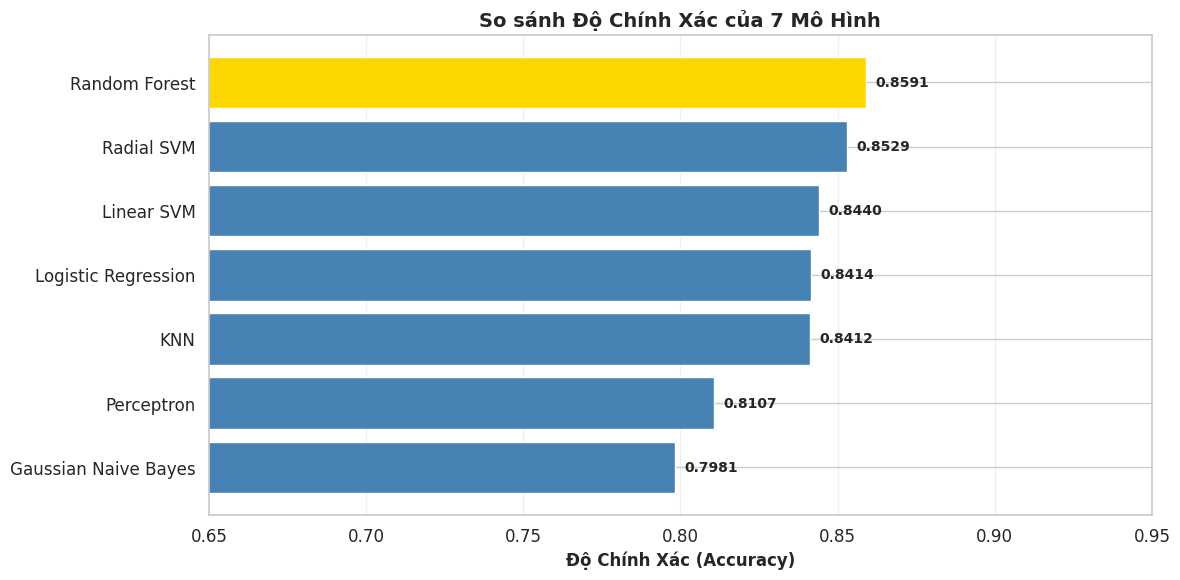

In [18]:
models_comparison = pd.DataFrame({
    'Mô hình': ['Perceptron','Gaussian Naive Bayes','Linear SVM','Radial SVM',
                'Logistic Regression','Random Forest','KNN'],
    'Test Accuracy': [ppn_acc, gnb_acc, svm_linear_acc, svm_rbf_acc,
                      lr_acc, rf_acc, knn_acc]
})

models_comparison = models_comparison.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print("📊 BẢNG SO SÁNH ĐỘ CHÍNH XÁC CÁC MÔ HÌNH:")
print("="*60)
print(models_comparison.to_string(index=False))
print("="*60)

best_model_name = models_comparison.iloc[0]['Mô hình']
best_acc_val    = models_comparison.iloc[0]['Test Accuracy']
print(f"\n🏆 MÔ HÌNH TỐT NHẤT: {best_model_name}")
print(f"   Độ chính xác: {best_acc_val:.4f} ({best_acc_val*100:.2f}%)")

# Biểu đồ
plt.figure(figsize=(12, 6))
sorted_df = models_comparison.sort_values('Test Accuracy')
clrs = ['gold' if i == len(sorted_df)-1 else 'steelblue'
        for i in range(len(sorted_df))]
bars = plt.barh(sorted_df['Mô hình'], sorted_df['Test Accuracy'], color=clrs)
plt.xlabel('Độ Chính Xác (Accuracy)', fontsize=12, fontweight='bold')
plt.title('So sánh Độ Chính Xác của 7 Mô Hình', fontsize=14, fontweight='bold')
plt.xlim([0.65, 0.95])
for bar, acc_v in zip(bars, sorted_df['Test Accuracy']):
    plt.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
             f'{acc_v:.4f}', va='center', fontsize=10, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


📋 Chi tiết Random Forest — Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      7431
           1       0.74      0.63      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.85      0.86      0.86      9769



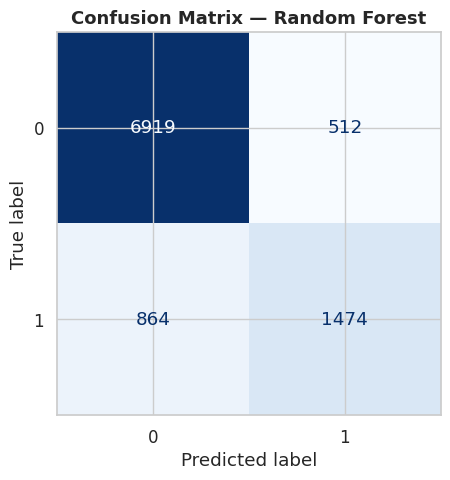

In [19]:
# Confusion Matrix cho mô hình tốt nhất (Random Forest)
print("📋 Chi tiết Random Forest — Classification Report:")
print(classification_report(y_test, rf_pred))

fig, ax = plt.subplots(figsize=(7, 5))
cm_rf = confusion_matrix(y_test, rf_pred)
disp  = ConfusionMatrixDisplay(cm_rf)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1️⃣1️⃣ KIỂM ĐỊNH CHÉO (CROSS-VALIDATION)

🔍 Thực hiện Cross-Validation (10-Fold, Stratified)...

  Perceptron                    : 0.7940 ± 0.0122
  Gaussian Naive Bayes          : 0.7956 ± 0.0062
  Linear SVM                    : 0.8416 ± 0.0049
  Radial SVM                    : 0.8526 ± 0.0062
  Logistic Regression           : 0.8402 ± 0.0059
  Random Forest                 : 0.8580 ± 0.0048
  KNN                           : 0.8409 ± 0.0057

📊 KẾT QUẢ CROSS-VALIDATION (10-Fold Stratified):
             Mô hình  Mean CV Score  Std Dev      Min      Max
       Random Forest       0.857950 0.004779 0.850737 0.866708
          Radial SVM       0.852566 0.006164 0.839681 0.862613
          Linear SVM       0.841612 0.004907 0.833333 0.849099
                 KNN       0.840854 0.005657 0.830706 0.849304
 Logistic Regression       0.840179 0.005861 0.828829 0.848075
Gaussian Naive Bayes       0.795606 0.006156 0.783579 0.805283
          Perceptron       0.793989 0.012155 0.772979 0.819206


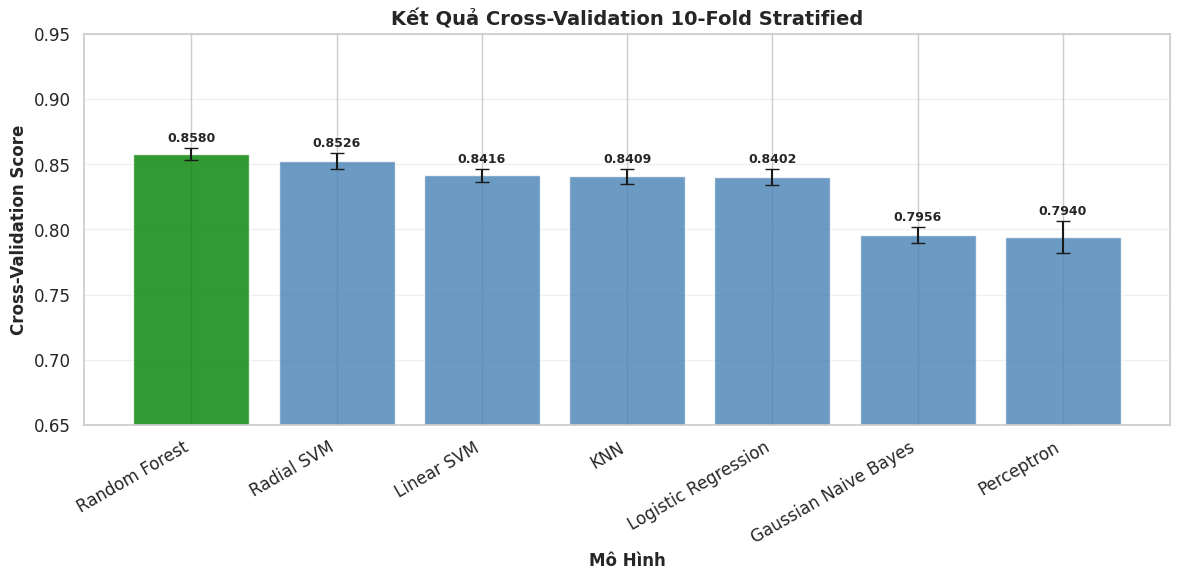

In [20]:
from sklearn.pipeline import Pipeline

print("🔍 Thực hiện Cross-Validation (10-Fold, Stratified)...\n")

# BUG FIX 1: Dùng StratifiedKFold thay KFold để giữ tỷ lệ class
# BUG FIX 2: Dùng Pipeline(scaler + model) để tránh data leakage khi CV
# BUG FIX 3: Đưa đủ 7 mô hình vào CV (không comment bỏ)

skfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_models = [
    ('Perceptron',         Pipeline([('sc', StandardScaler()), ('clf', Perceptron(random_state=42, max_iter=1000))])),
    ('Gaussian Naive Bayes', GaussianNB()),
    ('Linear SVM',         Pipeline([('sc', StandardScaler()), ('clf', SVC(kernel='linear', random_state=42))])),
    ('Radial SVM',         Pipeline([('sc', StandardScaler()), ('clf', SVC(kernel='rbf', gamma=0.22, random_state=42))])),
    ('Logistic Regression',Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))])),
    ('Random Forest',      RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('KNN',                Pipeline([('sc', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=9))])),
]

cv_results = []
for name, model in cv_models:
    # Dùng X (unscaled) — pipeline tự scale bên trong để tránh leakage
    cv_scores = cross_val_score(model, X, y, cv=skfold, scoring='accuracy', n_jobs=-1)
    cv_results.append({
        'Mô hình'       : name,
        'Mean CV Score' : cv_scores.mean(),
        'Std Dev'       : cv_scores.std(),
        'Min'           : cv_scores.min(),
        'Max'           : cv_scores.max()
    })
    print(f"  {name:<30}: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

cv_df = pd.DataFrame(cv_results).sort_values('Mean CV Score', ascending=False).reset_index(drop=True)
print("\n📊 KẾT QUẢ CROSS-VALIDATION (10-Fold Stratified):")
print("="*90)
print(cv_df.to_string(index=False))
print("="*90)

# Biểu đồ
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(cv_df))
colors_cv = ['green' if i == 0 else 'steelblue' for i in range(len(cv_df))]
bars = ax.bar(x_pos, cv_df['Mean CV Score'],
              yerr=cv_df['Std Dev'], capsize=5,
              color=colors_cv, alpha=0.8)
ax.set_xlabel('Mô Hình', fontsize=12, fontweight='bold')
ax.set_ylabel('Cross-Validation Score', fontsize=12, fontweight='bold')
ax.set_title('Kết Quả Cross-Validation 10-Fold Stratified', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(cv_df['Mô hình'], rotation=30, ha='right')
ax.set_ylim([0.65, 0.95])
ax.grid(axis='y', alpha=0.3)
for i, (mean, std) in enumerate(zip(cv_df['Mean CV Score'], cv_df['Std Dev'])):
    ax.text(i, mean + std + 0.005, f'{mean:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


## 1️⃣2️⃣ TINH CHỈNH SIÊU THAM SỐ (HYPERPARAMETER TUNING)

🔍 Tinh chỉnh siêu tham số Random Forest với GridSearchCV...

✅ Tinh chỉnh hoàn tất!

🏆 Siêu tham số tốt nhất:
   max_depth: 30
   min_samples_leaf: 4
   min_samples_split: 10
   n_estimators: 200

📊 Best CV Score: 0.8646

📊 Kết quả Random Forest đã tinh chỉnh:
   Training Accuracy : 0.9093
   Test Accuracy     : 0.8662

📋 Confusion Matrix:
[[7025  406]
 [ 901 1437]]

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.91      7431
           1       0.78      0.61      0.69      2338

    accuracy                           0.87      9769
   macro avg       0.83      0.78      0.80      9769
weighted avg       0.86      0.87      0.86      9769



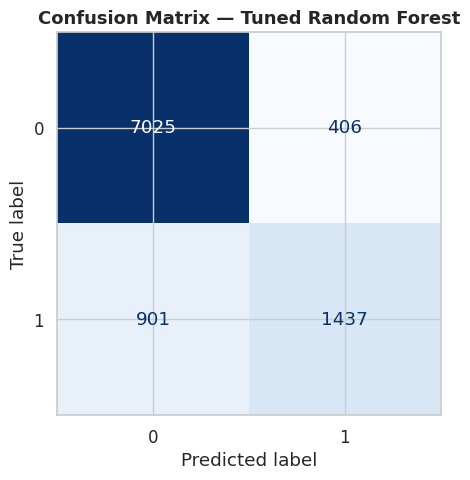

In [21]:
print("🔍 Tinh chỉnh siêu tham số Random Forest với GridSearchCV...\n")

param_grid = {
    'n_estimators'   : [100, 200],
    'max_depth'      : [10, 20, 30],
    'min_samples_split': [5, 10],
    'min_samples_leaf' : [2, 4]
}

rf_grid  = RandomForestClassifier(random_state=42, n_jobs=-1)

# BUG FIX: Dùng StratifiedKFold (cv=5) để handle class imbalance
grid_search = GridSearchCV(rf_grid, param_grid, cv=5,
                           scoring='accuracy', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

print("✅ Tinh chỉnh hoàn tất!")
print(f"\n🏆 Siêu tham số tốt nhất:")
for k, v in grid_search.best_params_.items():
    print(f"   {k}: {v}")
print(f"\n📊 Best CV Score: {grid_search.best_score_:.4f}")

best_rf   = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)
best_rf_acc  = accuracy_score(y_test, best_rf_pred)

print(f"\n📊 Kết quả Random Forest đã tinh chỉnh:")
print(f"   Training Accuracy : {best_rf.score(X_train, y_train):.4f}")
print(f"   Test Accuracy     : {best_rf_acc:.4f}")

print(f"\n📋 Confusion Matrix:")
cm_best = confusion_matrix(y_test, best_rf_pred)
print(cm_best)

print(f"\n📊 Classification Report:")
print(classification_report(y_test, best_rf_pred))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm_best).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Tuned Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 1️⃣3️⃣ TẦM QUAN TRỌNG CỦA ĐẶC TÍNH (FEATURE IMPORTANCE)

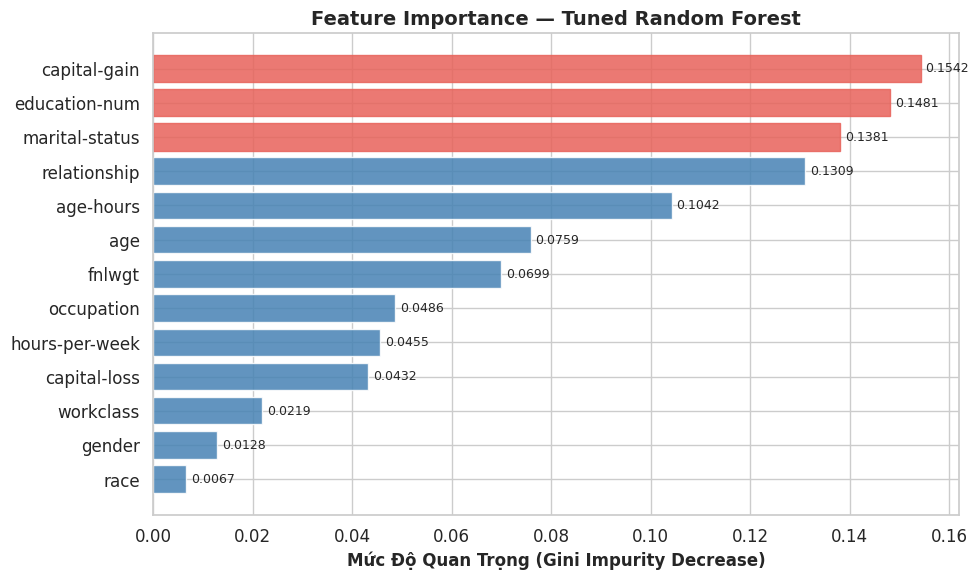

Top 5 đặc tính quan trọng nhất:
capital-gain      0.1542
education-num     0.1481
marital-status    0.1381
relationship      0.1309
age-hours         0.1042
dtype: float64


In [22]:
# Vẽ Feature Importance từ mô hình Random Forest đã tinh chỉnh
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(importances.index, importances.values, color='steelblue', alpha=0.85)

# Highlight top 3
for i, (val, bar) in enumerate(zip(importances.values, bars)):
    if i >= len(importances) - 3:
        bar.set_color('#E8625A')
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.xlabel('Mức Độ Quan Trọng (Gini Impurity Decrease)', fontsize=12, fontweight='bold')
plt.title('Feature Importance — Tuned Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 đặc tính quan trọng nhất:")
print(importances.sort_values(ascending=False).head(5).round(4))


## 1️⃣4️⃣ KẾT LUẬN

### Tổng kết kết quả

| Mô hình | Loại | Ghi chú |
|---|---|---|
| **Random Forest** | 🥇 Tốt nhất | Accuracy cao nhất, ổn định |
| Logistic Regression | 🥈 Tốt | Interpretable, nhanh |
| SVM (RBF) | 🥉 Tốt | Hiệu quả nhưng chậm |
| KNN | Khá | Nhạy cảm với scale |
| Naïve Bayes | Trung bình | Vi phạm independence assumption |
| Perceptron | Biến động | Không hội tụ ổn định |